In [0]:
import requests
import pandas as pd
import sqlite3
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, roc_auc_score, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from pulp import *


In [0]:
# #Pull from DataGolf API
# response = requests.get(
#     "https://feeds.datagolf.com/preds/player-skill-ratings",
#     params={"api_key": "your_key", "format": "json"}
# )

# https://datagolf.com/api-access  for later

In [0]:
# download latest version
path = kagglehub.dataset_download("robikscube/pga-tour-golf-data-20152022")
print("Path to dataset files:", path)

# Concatenate file name to path
file_path = os.path.join(path, "ASA All PGA Raw Data - Tourn Level.csv")

# Load into dataframe
df = pd.read_csv(file_path)
df.head()

Path to dataset files: /home/spark-ff353d92-01a0-469d-a98d-5e/.cache/kagglehub/datasets/robikscube/pga-tour-golf-data-20152022/versions/1


,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,streak_SDP,n_rounds,made_cut,pos,finish_DKP,finish_FDP,finish_SDP,total_DKP,total_FDP,total_SDP,player,Unnamed: 2,Unnamed: 3,Unnamed: 4,tournament name,course,date,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,3,4,1,32.0,2,1,0,65.0,59.7,59,Abraham Ancer,NaN,NaN,NaN,The Memorial Tournament pres. by Nationwide,"Muirfield Village Golf Club - Dublin, OH",2022-06-05,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,3,4,1,18.0,5,4,2,85.5,78.5,66,Adam Hadwin,NaN,NaN,NaN,The Memorial Tournament pres. by Nationwide,"Muirfield Village Golf Club - Dublin, OH",2022-06-05,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60
2,A. Lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,0,2,0,NaN,0,0,0,21.5,17.4,27,Anirban Lahiri,NaN,NaN,NaN,The Memorial Tournament pres. by Nationwide,"Muirfield Village Golf Club - Dublin, OH",2022-06-05,12.0,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54
3,A. Long,401353224,6015,144,151,20.5,13.6,17,0,0.4,0,2,0,NaN,0,0,0,20.5,14.0,17,Adam Long,NaN,NaN,NaN,The Memorial Tournament pres. by Nationwide,"Muirfield Village Golf Club - Dublin, OH",2022-06-05,12.0,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54
4,A. Noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,0,2,0,NaN,0,0,0,23.5,19.3,23,Alexander Noren,NaN,NaN,NaN,The Memorial Tournament pres. by Nationwide,"Muirfield Village Golf Club - Dublin, OH",2022-06-05,12.0,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04


In [0]:
# First look
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(36864, 37)
['Player_initial_last', 'tournament id', 'player id', 'hole_par', 'strokes', 'hole_DKP', 'hole_FDP', 'hole_SDP', 'streak_DKP', 'streak_FDP', 'streak_SDP', 'n_rounds', 'made_cut', 'pos', 'finish_DKP', 'finish_FDP', 'finish_SDP', 'total_DKP', 'total_FDP', 'total_SDP', 'player', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'tournament name', 'course', 'date', 'purse', 'season', 'no_cut', 'Finish', 'sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'sg_total']
  Player_initial_last  tournament id  player id  ...  sg_ott  sg_t2g  sg_total
0            A. Ancer      401353224       9261  ...    0.86    0.65      0.85
1           A. Hadwin      401353224       5548  ...    0.18    1.24      1.60
2           A. Lahiri      401353224       4989  ...    0.37    0.02     -0.54
3             A. Long      401353224       6015  ...    0.80   -1.08     -2.54
4            A. Noren      401353224       3832  ...    0.19   -1.56     -1.04

[5 rows x 37 columns]
Player_initial_last     object
to

In [0]:
# Clean up data
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

# Check for nulls
print(df.isnull().sum())

Player_initial_last        0
tournament id              0
player id                  0
hole_par                   0
strokes                    0
hole_DKP                   0
hole_FDP                   0
hole_SDP                   0
streak_DKP                 0
streak_FDP                 0
streak_SDP                 0
n_rounds                   0
made_cut                   0
pos                    15547
finish_DKP                 0
finish_FDP                 0
finish_SDP                 0
total_DKP                  0
total_FDP                  0
total_SDP                  0
player                     0
tournament name            0
course                     0
date                       0
purse                      0
season                     0
no_cut                     0
Finish                  7683
sg_putt                 7684
sg_arg                  7684
sg_app                  7684
sg_ott                  7684
sg_t2g                  7684
sg_total                7683
dtype: int64


In [0]:
# Check seasons available
print(df['season'].value_counts().sort_index())

season
2015    4174
2016    4165
2017    4745
2018    4979
2019    5150
2020    4287
2021    5688
2022    3676
Name: count, dtype: int64


In [0]:
# Check made_cut distribution
print(df['made_cut'].value_counts())

made_cut
1    22336
0    14528
Name: count, dtype: int64


In [0]:
# Basic strokes gained stats
print(df[['sg_putt','sg_arg','sg_app','sg_ott','sg_total']].describe())

            sg_putt        sg_arg        sg_app        sg_ott      sg_total
count  29180.000000  29180.000000  29180.000000  29180.000000  29181.000000
mean      -0.121005     -0.040744     -0.101759     -0.045896     -0.305491
std        1.119451      0.727315      1.119763      0.808139      1.966669
min       -5.990000     -6.430000     -9.250000     -7.740000    -13.670000
25%       -0.770000     -0.450000     -0.740000     -0.450000     -1.370000
50%       -0.040000      0.000000      0.000000      0.050000     -0.160000
75%        0.630000      0.420000      0.640000      0.480000      1.060000
max        4.430000      3.170000      4.670000      2.770000      8.520000


In [0]:
# Filter to rows where we have strokes gained data
df_model = df.dropna(subset=['sg_putt','sg_arg','sg_app','sg_ott','sg_total'])

# Features and target
features = ['sg_putt','sg_arg','sg_app','sg_ott','sg_total']
X = df_model[features]
y = df_model['made_cut']

# Train/test split data - split by season to avoid data leakage
train = df_model[df_model['season'] <= 2020]
test = df_model[df_model['season'] > 2020]

X_train = train[features]
y_train = train['made_cut']
X_test = test[features]
y_test = test['made_cut']

# Build Model
model = GradientBoostingClassifier(n_estimators = 100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC: ", roc_auc_score(y_test, y_prob))

# Feature Importance
for feat, imp in zip(features, model.feature_importances_):
    print(f"{feat}: {imp:.3f}")

              precision    recall  f1-score   support

           0       0.77      0.81      0.79      3423
           1       0.85      0.81      0.83      4447

    accuracy                           0.81      7870
   macro avg       0.81      0.81      0.81      7870
weighted avg       0.81      0.81      0.81      7870

ROC-AUC:  0.8960160572000635
sg_putt: 0.026
sg_arg: 0.018
sg_app: 0.019
sg_ott: 0.015
sg_total: 0.921


In [0]:
# Remove sg_total and use only components
features_no_total = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott']

X_train2 = train[features_no_total]
X_test2 = test[features_no_total]

model2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
model2.fit(X_train2, y_train)

y_pred2 = model2.predict(X_test2)
y_prob2 = model2.predict_proba(X_test2)[:,1]

print(classification_report(y_test, y_pred2))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob2):.3f}")

for feat, imp in zip(features_no_total, model2.feature_importances_):
    print(f"{feat}: {imp:.3f}")

              precision    recall  f1-score   support

           0       0.78      0.75      0.77      3423
           1       0.81      0.84      0.83      4447

    accuracy                           0.80      7870
   macro avg       0.80      0.79      0.80      7870
weighted avg       0.80      0.80      0.80      7870

ROC-AUC: 0.884
sg_putt: 0.350
sg_arg: 0.151
sg_app: 0.337
sg_ott: 0.161


<b>Finding:</b> Putting and approach play are the primary determinants of making the cut on the PGA tour, accounting for 69% of combined feature importance in a gradient boosting model trained on 8 seasons of strokes gained data.

In [0]:
# Encode course and tournament
df_model2 = df.dropna(subset=['sg_putt', 'sg_arg', 'sg_app', 'sg_ott'])

# Encode categorical variables
le_course = LabelEncoder()
le_tournament = LabelEncoder()

df_model2['course_encoded'] = le_course.fit_transform(df_model2['course'])
df_model2['tournament_encoded'] = le_tournament.fit_transform(df_model2['tournament name'])

# New feature set with course and tournament
features_with_course = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'course_encoded', 'tournament_encoded']

train2 = df_model2[df_model2['season'] <= 2020]
test2 = df_model2[df_model2['season'] > 2020]

X_train3 = train2[features_with_course]
y_train3 = train2['made_cut']
X_test3 = test2[features_with_course]
y_test3 = test2['made_cut']

model3 = GradientBoostingClassifier(n_estimators=100, random_state=42)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
y_prob3 = model3.predict_proba(X_test3)[:,1]

print(classification_report(y_test3, y_pred3))
print(f"ROC-AUC: {roc_auc_score(y_test3, y_prob3):.3f}")

for feat, imp in zip(features_with_course, model3.feature_importances_):
    print(f"{feat}: {imp:.3f}")

/home/spark-ff353d92-01a0-469d-a98d-5e/.ipykernel/305/command-7050569456234491-3914704516:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model2['course_encoded'] = le_course.fit_transform(df_model2['course'])
/home/spark-ff353d92-01a0-469d-a98d-5e/.ipykernel/305/command-7050569456234491-3914704516:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model2['tournament_encoded'] = le_tournament.fit_transform(df_model2['tournament name'])


              precision    recall  f1-score   support

           0       0.80      0.74      0.77      3423
           1       0.81      0.86      0.84      4447

    accuracy                           0.81      7870
   macro avg       0.81      0.80      0.80      7870
weighted avg       0.81      0.81      0.81      7870

ROC-AUC: 0.891
sg_putt: 0.300
sg_arg: 0.131
sg_app: 0.284
sg_ott: 0.142
course_encoded: 0.062
tournament_encoded: 0.081


<b>Finding: </b> Individual strokes gained metrics explain ~86% of cut-making predictability, while course and tournament context add an additional ~14% of explanatory power. This suggests course fit adjustments should be considered but not override fundamental skill assessments in DFS lineup construction.

count    29180.000000
mean        53.634236
std         28.898551
min         -2.500000
25%         27.000000
50%         54.000000
75%         74.500000
max        205.500000
Name: total_DKP, dtype: float64

Rows available: 29180


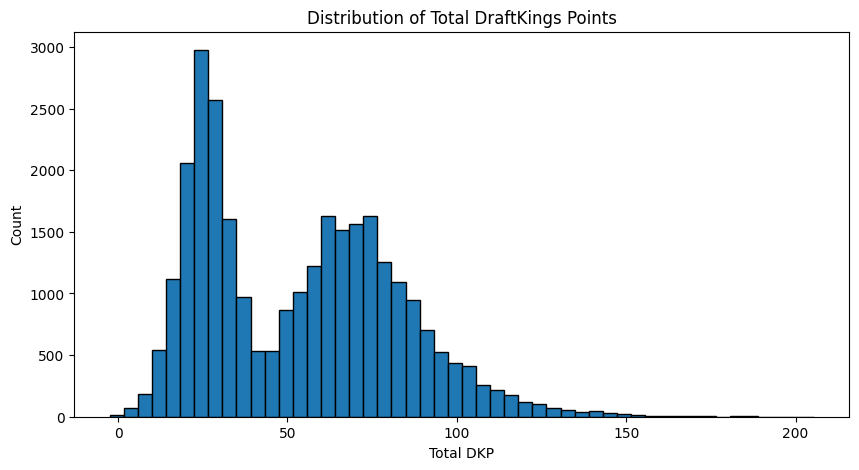

total_DKP    1.000000
sg_total     0.755807
sg_app       0.462436
sg_putt      0.454094
sg_ott       0.318601
sg_arg       0.276825
Name: total_DKP, dtype: float64


In [0]:
# Filter to players with DKP data and strokes gained
df_dkp = df.dropna(subset=['sg_putt', 'sg_arg', 'sg_app', 'sg_ott','total_DKP'])

# View distribution
print(df_dkp['total_DKP'].describe())
print(f"\nRows available: {len(df_dkp)}")

# Plot distribution
plt.figure(figsize=(10,5))
plt.hist(df_dkp['total_DKP'], bins=50, edgecolor='black')
plt.title('Distribution of Total DraftKings Points')
plt.xlabel('Total DKP')
plt.ylabel('Count')
plt.show()

# Check correlation between SG and DKP
correlations = df_dkp[['sg_putt', 'sg_arg', 'sg_app', 'sg_ott','sg_total','total_DKP']].corr()
print(correlations['total_DKP'].sort_values(ascending=False))

<b>Finding: </b> The first hump around 25-30 DKP are players that missed the cut who only played two rounds in a tournament. The other hump, 60-80 DKP are players who made the cut and played four rounds. We will filter the data to players that made the cut, since I don't want to pick a player who i think will miss the cut.

In [0]:
# Filter to made cut players only
df_made_cut = df_dkp[df_dkp['made_cut'] == 1].copy()

# Encode course and tournament
df_made_cut['course_encoded'] = le_course.transform(
    df_made_cut['course'].map(
        lambda x: x if x in le_course.classes_ else le_course.classes_[0]
    )
)
df_made_cut['tournament_encoded'] = le_tournament.transform(
    df_made_cut['tournament name'].map(
        lambda x: x if x in le_tournament.classes_ else le_tournament.classes_[0]
    )
)

features_reg = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 
                'course_encoded', 'tournament_encoded']

train_reg = df_made_cut[df_made_cut['season'] <= 2020]
test_reg = df_made_cut[df_made_cut['season'] > 2020]

X_train_r = train_reg[features_reg]
y_train_r = train_reg['total_DKP']
X_test_r = test_reg[features_reg]
y_test_r = test_reg['total_DKP']

model_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_reg.fit(X_train_r, y_train_r)

y_pred_r = model_reg.predict(X_test_r)

print(f"MAE: {mean_absolute_error(y_test_r, y_pred_r):.2f} DKP points")
print(f"R²: {r2_score(y_test_r, y_pred_r):.3f}")

for feat, imp in zip(features_reg, model_reg.feature_importances_):
    print(f"{feat}: {imp:.3f}")

MAE: 10.99 DKP points
R²: 0.475
sg_putt: 0.271
sg_arg: 0.086
sg_app: 0.253
sg_ott: 0.146
course_encoded: 0.166
tournament_encoded: 0.079


In [0]:
# Add purse as a proxy for field strength
# Add n_rounds in case some tournaments have different formats
features_reg2 = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott',
                 'course_encoded', 'tournament_encoded', 
                 'purse', 'n_rounds']

X_train_r2 = train_reg[features_reg2]
X_test_r2 = test_reg[features_reg2]
y_train_r2 = train_reg['total_DKP']
y_test_r2 = test_reg['total_DKP']

model_reg2 = GradientBoostingRegressor(n_estimators=200, 
                                        max_depth=4,
                                        learning_rate=0.05,
                                        random_state=42)
model_reg2.fit(X_train_r2, y_train_r2)

y_pred_r2 = model_reg2.predict(X_test_r2)

print(f"MAE: {mean_absolute_error(y_test_r2, y_pred_r2):.2f} DKP points")
print(f"R²: {r2_score(y_test_r2, y_pred_r2):.3f}")

for feat, imp in zip(features_reg2, model_reg2.feature_importances_):
    print(f"{feat}: {imp:.3f}")

MAE: 10.47 DKP points
R²: 0.505
sg_putt: 0.224
sg_arg: 0.077
sg_app: 0.219
sg_ott: 0.125
course_encoded: 0.105
tournament_encoded: 0.052
purse: 0.107
n_rounds: 0.090


In [0]:
from scipy.optimize import linprog

# We'll use purse-based salary simulation for now
# In practice you'd scrape or manually input DK salaries

# Get test set predictions with player names
test_reg_copy = test_reg.copy()
test_reg_copy['predicted_DKP'] = y_pred_r2

# Simulate salary based on predicted DKP
# Higher projected score = higher salary (like DraftKings does it)
test_reg_copy['simulated_salary'] = (
    test_reg_copy['predicted_DKP'] / 
    test_reg_copy['predicted_DKP'].max() * 10000 + 4000
).round(-2)

# Pick one tournament to optimize
tournament_example = test_reg_copy['tournament name'].value_counts().index[0]
field = test_reg_copy[test_reg_copy['tournament name'] == tournament_example].copy()

print(f"Optimizing for: {tournament_example}")
print(f"Field size: {len(field)} players")
print(field[['player', 'predicted_DKP', 'simulated_salary']].sort_values(
    'predicted_DKP', ascending=False).head(10))

Optimizing for: The American Express
Field size: 209 players
                  player  predicted_DKP  simulated_salary
7703          Si Woo Kim     134.111900           12600.0
7677     Patrick Cantlay     125.309009           12000.0
2376     Hudson Swafford     124.469307           12000.0
2402       Lanto Griffin     120.614829           11700.0
7603       Cameron Davis     117.531275           11500.0
2368  Francesco Molinari     111.992587           11200.0
2403          Lee Hodges     108.417408           11000.0
7678          Paul Casey     107.272871           10900.0
2433          Sungjae Im     106.860340           10900.0
7628    Henrik Norlander     105.074392           10700.0


In [0]:
def optimize_lineup(field_df, salary_cap=50000, roster_size=6):
    """
    Optimize DraftKings golf lineup
    field_df: dataframe with player, predicted_DKP, simulated_salary
    """
    
    # Create the problem
    prob = LpProblem("DraftKings_Golf_Optimizer", LpMaximize)
    
    # Decision variables - 1 if player is selected, 0 if not
    players = field_df['player'].tolist()
    x = LpVariable.dicts("player", players, cat='Binary')
    
    # Objective - maximize total predicted DKP
    prob += lpSum([field_df.loc[field_df['player']==p, 'predicted_DKP'].values[0] * x[p] 
                   for p in players])
    
    # Constraints
    # Salary cap
    prob += lpSum([field_df.loc[field_df['player']==p, 'simulated_salary'].values[0] * x[p] 
                   for p in players]) <= salary_cap
    
    # Exactly 6 players
    prob += lpSum([x[p] for p in players]) == roster_size
    
    # Solve
    prob.solve(PULP_CBC_CMD(msg=0))
    
    # Extract results
    selected = [p for p in players if x[p].value() == 1]
    lineup = field_df[field_df['player'].isin(selected)][
        ['player', 'predicted_DKP', 'simulated_salary']
    ].sort_values('predicted_DKP', ascending=False)
    
    total_salary = lineup['simulated_salary'].sum()
    total_projected = lineup['predicted_DKP'].sum()
    
    return lineup, total_salary, total_projected

# Install pulp first - run this in a separate cell
# !pip install pulp

# Run the optimizer
lineup, total_salary, total_projected = optimize_lineup(field)

print(f"Optimal Lineup for: {tournament_example}")
print(f"Total Salary Used: ${total_salary:,.0f} / $50,000")
print(f"Total Projected DKP: {total_projected:.1f}")
print()
print(lineup.to_string(index=False))

Optimal Lineup for: The American Express
Total Salary Used: $51,600 / $50,000
Total Projected DKP: 434.7

          player  predicted_DKP  simulated_salary
Henrik Norlander     105.074392           10700.0
    Hank Lebioda      78.750953            9000.0
    Lucas Glover      72.492100            8600.0
Henrik Norlander      67.805080            8300.0
    Hank Lebioda      66.133269            8200.0
    Carlos Ortiz      44.441032            6800.0


In [0]:
print(field.groupby('player').size().sort_values(ascending=False).head(10))


player
Abraham Ancer      2
Adam Hadwin        2
Brian Stuard       2
Adam Long          2
Adam Schenk        2
Alexander Noren    2
Andrew Putnam      2
Andrew Landry      2
Brandon Hagy       2
Austin Cook        2
dtype: int64


In [0]:
field_agg = field.groupby('player').agg({
    'predicted_DKP': 'mean',
    'simulated_salary': 'mean'
}).reset_index()

print(f"Field size after dedup: {len(field_agg)}")
print(field_agg.sort_values('predicted_DKP', ascending=False).head(10))

Field size after dedup: 162
              player  predicted_DKP  simulated_salary
64   Hudson Swafford     124.469307           12000.0
90     Lanto Griffin     120.614829           11700.0
28     Cameron Davis     117.531275           11500.0
143       Si Woo Kim     115.488067           11400.0
91        Lee Hodges     108.417408           11000.0
116       Paul Casey     107.272871           10900.0
150       Tony Finau     102.637698           10550.0
49    Denny McCarthy      99.822179           10400.0
111  Patrick Cantlay      98.440740           10300.0
145       Sungjae Im      97.771056           10300.0


In [0]:
# Run optimizer on deduplicated field
lineup, total_salary, total_projected = optimize_lineup(field_agg)

print(f"Optimal Lineup for: {tournament_example}")
print(f"Total Salary Used: ${total_salary:,.0f} / $50,000")
print(f"Total Projected DKP: {total_projected:.1f}")
print()
print(lineup.to_string(index=False))

Optimal Lineup for: The American Express
Total Salary Used: $50,000 / $50,000
Total Projected DKP: 409.9

       player  predicted_DKP  simulated_salary
  Ryan Armour      88.004862            9600.0
 Lucas Glover      72.492100            8600.0
 Hank Lebioda      72.442111            8600.0
  Josh Teater      69.376287            8400.0
Vaughn Taylor      63.142954            8000.0
 Carlos Ortiz      44.441032            6800.0


In [0]:
def optimize_lineup(field_df, salary_cap=50000, roster_size=6, min_projection=60):
    
    # Filter out low projected players
    field_df = field_df[field_df['predicted_DKP'] >= min_projection].copy()
    
    prob = LpProblem("DraftKings_Golf_Optimizer", LpMaximize)
    
    players = field_df['player'].tolist()
    x = LpVariable.dicts("player", players, cat='Binary')
    
    prob += lpSum([field_df.loc[field_df['player']==p, 'predicted_DKP'].values[0] * x[p] 
                   for p in players])
    
    prob += lpSum([field_df.loc[field_df['player']==p, 'simulated_salary'].values[0] * x[p] 
                   for p in players]) <= salary_cap
    
    prob += lpSum([x[p] for p in players]) == roster_size
    
    prob.solve(PULP_CBC_CMD(msg=0))
    
    selected = [p for p in players if x[p].value() == 1]
    lineup = field_df[field_df['player'].isin(selected)][
        ['player', 'predicted_DKP', 'simulated_salary']
    ].sort_values('predicted_DKP', ascending=False)
    
    total_salary = lineup['simulated_salary'].sum()
    total_projected = lineup['predicted_DKP'].sum()
    
    return lineup, total_salary, total_projected

lineup, total_salary, total_projected = optimize_lineup(field_agg, min_projection=60)

print(f"Optimal Lineup for: {tournament_example}")
print(f"Total Salary Used: ${total_salary:,.0f} / $50,000")
print(f"Total Projected DKP: {total_projected:.1f}")
print()
print(lineup.to_string(index=False))

Optimal Lineup for: The American Express
Total Salary Used: $50,000 / $50,000
Total Projected DKP: 409.8

        player  predicted_DKP  simulated_salary
  Lucas Glover      72.492100            8600.0
  Hank Lebioda      72.442111            8600.0
   Josh Teater      69.376287            8400.0
Rory Sabbatini      67.706658            8300.0
  Taylor Moore      64.619614            8100.0
 Vaughn Taylor      63.142954            8000.0
